In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression

In [13]:
# Generate a synthetic dataset
X, y = make_regression(n_samples=10000, n_features=1, noise=20, random_state=42)

#Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [14]:
# Fir regression model
model = LinearRegression().fit(X_train, y_train)

# Predict the values using the test set
y_pred = model.predict(X_test)

Text(0, 0.5, 'Residuals')

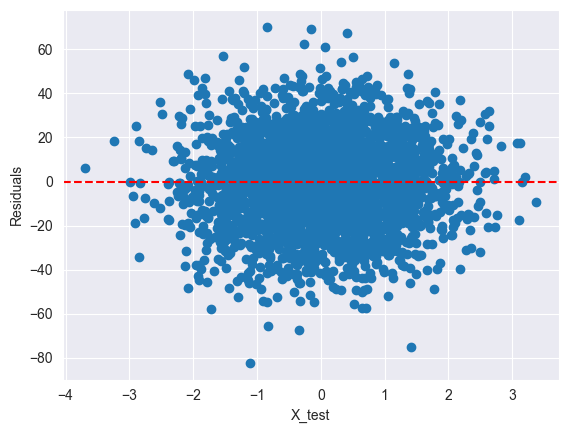

In [15]:
# Residuals
residuals = y_test - y_pred

#Plot residuals
plt.scatter(X_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('X_test')
plt.ylabel('Residuals')

Todo se ve aparentemente bien, en caso de que viéramos un embudo podríamos considerar que tenemos no homo-elasticidad.

A primera vista podemos ver que no tenemos ni un solo patron aparente

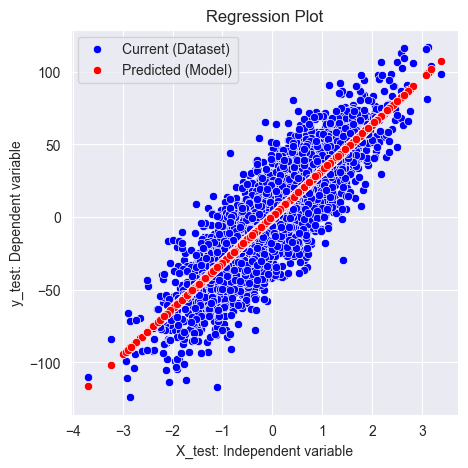

In [16]:
# Plotting data and regression
plt.figure(figsize=(5, 5))
sns.scatterplot(x=X_test.flatten(), y=y_test, label='Current (Dataset)', color='blue')
sns.scatterplot(x=X_test.flatten(), y=y_pred, label='Predicted (Model)', color='red')
plt.xlabel('X_test: Independent variable')
plt.ylabel('y_test: Dependent variable')
plt.title('Regression Plot')
plt.legend()
plt.show()

Vamos a comprar lo que tenemos en el dataset con lo que está generando el modelo.

Podemos ver diferencias mínimas en el conjunto de puntos en la parte superior, nada alarmante.

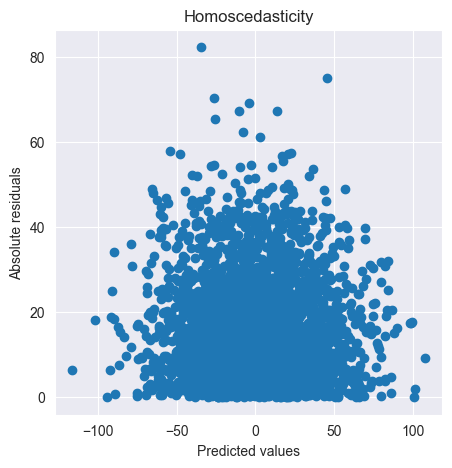

In [17]:
# Plot: Homoscedasticity
plt.figure(figsize=(5, 5))
plt.scatter(x=y_pred, y=np.abs(residuals))
plt.xlabel('Predicted values')
plt.ylabel('Absolute residuals')
plt.title('Homoscedasticity')
plt.show()

La forma de embudo nos indica que hay partes donde los errors son más pequeños o más grandes.

In [18]:
# Generate dataset
np.random.seed(42)
X_example = np.random.rand(200, 1) * 100
y_example = 2 * X_example.squeeze() + np.random.normal(0, X_example.squeeze(), 200)

# Split in test and train
X_train, X_test, y_train, y_test = train_test_split(X_example, y_example, test_size=0.3, random_state=42)

# Train a model
model_h = LinearRegression().fit(X_train, y_train)
y_pred_h = model_h.predict(X_test)

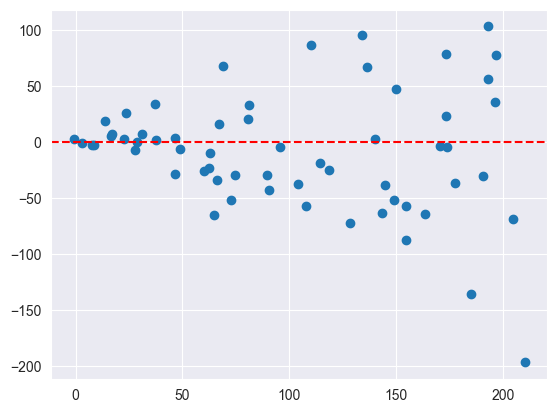

In [19]:
# Plot residual
residuals_h = y_test - y_pred_h
plt.scatter(y_pred_h, residuals_h)
plt.axhline(y=0, color='r', linestyle='--')

Se esta formando un embudo

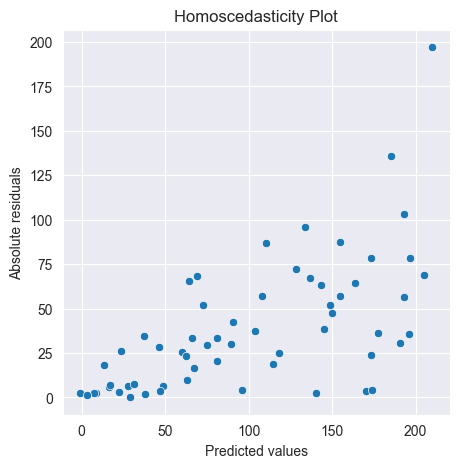

In [20]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_pred_h, y=np.abs(residuals_h))
plt.xlabel('Predicted values')
plt.ylabel('Absolute residuals')
plt.title('Homoscedasticity Plot')
plt.show()

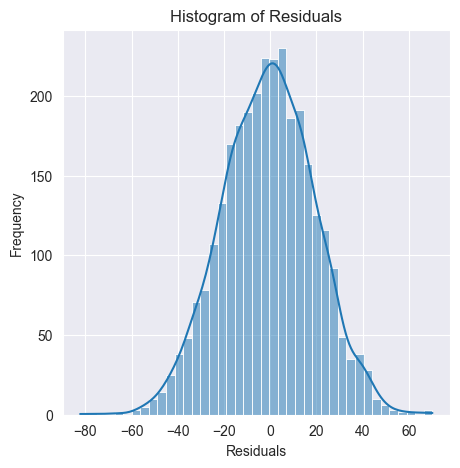

In [21]:
# Plot normality of residuals
plt.figure(figsize=(5, 5))
sns.histplot(residuals, kde=True) #KDE nos muestra la línea de la distribución
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

<Figure size 500x500 with 0 Axes>

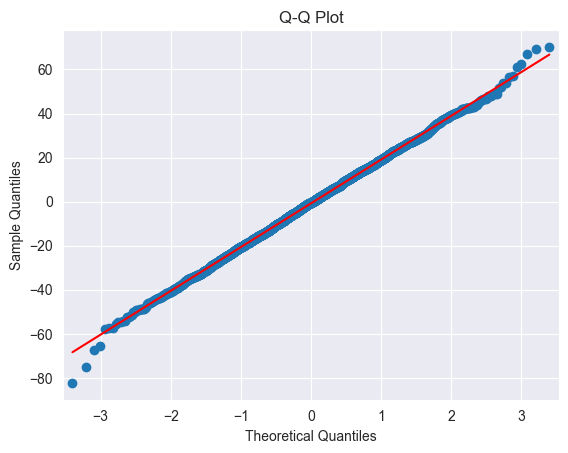

In [22]:
# Plot Q-Q plot
plt.figure(figsize=(5, 5))
sm.qqplot(residuals, line='s')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.title('Q-Q Plot')
plt.show()